In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import missingno as miss
import datetime as date
import keras_tuner
import os
import random
import matplotlib.pyplot as plt

SEED = 0

In [2]:
def set_seeds(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)

In [3]:
def set_global_determinism(seed=SEED):
    set_seeds(seed=seed)

    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)

# Call the above function with seed value
set_global_determinism(seed=SEED)

### My thoughts behind this process:
We look for the ideal mix of variables for real data and our training method. As a result, we will utilize our data for our training process—all variables from 2001 to 2019—and so on, to cut down on needless complexity.

In [4]:
#change the data here
rain=pd.read_csv("D:\\swaranjit\\merged\\merged\\Rangamati_data.csv")



<Axes: >

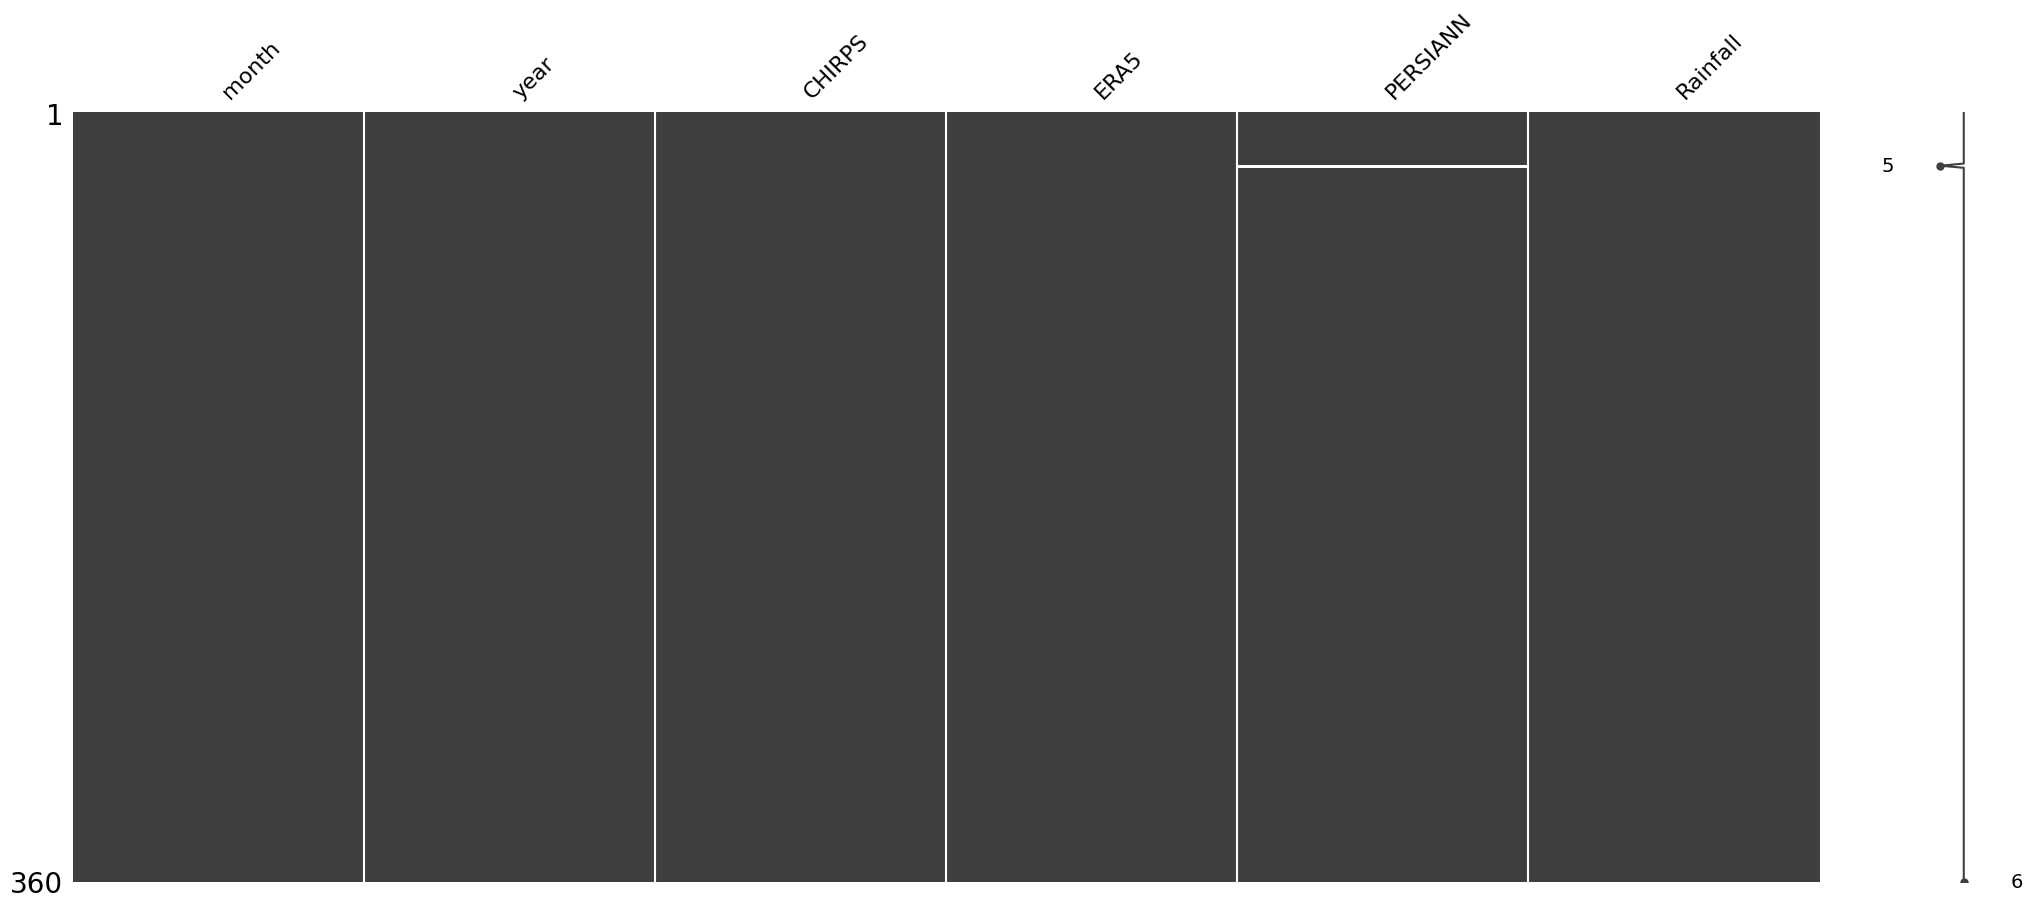

In [5]:
miss.matrix(rain)

In [6]:
rain["date"]=pd.to_datetime(rain[["year","month"]].assign(day=1))
rain

,month,year,CHIRPS,ERA5,PERSIANN,Rainfall,date
0,1,1990,4.022010,0.658017,0.000000,0,1990-01-01
1,2,1990,39.177370,52.641176,43.949623,22,1990-02-01
2,3,1990,51.477397,193.600386,205.449474,115,1990-03-01
3,4,1990,109.633575,103.459090,146.768341,336,1990-04-01
4,5,1990,212.974742,222.893030,299.063753,365,1990-05-01
...,...,...,...,...,...,...,...
355,8,2019,728.549629,237.429902,347.978541,355,2019-08-01
356,9,2019,326.231308,177.874804,291.731724,271,2019-09-01
357,10,2019,126.816886,114.427201,190.924931,170,2019-10-01
358,11,2019,123.799027,24.636718,90.437591,133,2019-11-01


In [7]:
rain=rain[["date","CHIRPS","ERA5","PERSIANN","Rainfall"]].dropna()

In [8]:
rain

,date,CHIRPS,ERA5,PERSIANN,Rainfall
0,1990-01-01,4.022010,0.658017,0.000000,0
1,1990-02-01,39.177370,52.641176,43.949623,22
2,1990-03-01,51.477397,193.600386,205.449474,115
3,1990-04-01,109.633575,103.459090,146.768341,336
4,1990-05-01,212.974742,222.893030,299.063753,365
...,...,...,...,...,...
355,2019-08-01,728.549629,237.429902,347.978541,355
356,2019-09-01,326.231308,177.874804,291.731724,271
357,2019-10-01,126.816886,114.427201,190.924931,170
358,2019-11-01,123.799027,24.636718,90.437591,133


In [9]:
from sklearn.preprocessing import power_transform
rain_new=pd.DataFrame(power_transform(rain[["CHIRPS","ERA5","PERSIANN","Rainfall"]], method='yeo-johnson'),columns=["CHIRPS","ERA5","PERSIANN","Rainfall"])

In [10]:
rain_new

,CHIRPS,ERA5,PERSIANN,Rainfall
0,-1.575648,-1.582047,-1.695021,-1.567435
1,-0.602723,-0.318810,-0.552649,-0.706382
2,-0.453490,0.567160,0.440282,0.075096
3,-0.002504,0.099237,0.180870,0.788170
4,0.442182,0.684447,0.763885,0.851530
...,...,...,...,...
354,1.400184,0.738592,0.905529,0.830124
355,0.753582,0.498878,0.741304,0.629561
356,0.090978,0.168911,0.381387,0.313281
357,0.075362,-0.698806,-0.147671,0.160997


In [11]:
rain[["CHIRPS","ERA5","PERSIANN","Rainfall"]]=rain_new[["CHIRPS","ERA5","PERSIANN","Rainfall"]]

In [12]:
rain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 359 entries, 0 to 359
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      359 non-null    datetime64[ns]
 1   CHIRPS    358 non-null    float64       
 2   ERA5      358 non-null    float64       
 3   PERSIANN  358 non-null    float64       
 4   Rainfall  358 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 16.8 KB


In [13]:
rain=rain.dropna()

### Cleaning the data with isolation forest

In [14]:
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.15)
outliers = iso_forest.fit_predict(rain.drop(["date"],axis=1))
rain_clean = rain[outliers == 1]
rain_clean

,date,CHIRPS,ERA5,PERSIANN,Rainfall
0,1990-01-01,-1.575648,-1.582047,-1.695021,-1.567435
1,1990-02-01,-0.602723,-0.318810,-0.552649,-0.706382
2,1990-03-01,-0.453490,0.567160,0.440282,0.075096
3,1990-04-01,-0.002504,0.099237,0.180870,0.788170
4,1990-05-01,0.442182,0.684447,0.763885,0.851530
...,...,...,...,...,...
354,2019-07-01,1.400184,0.738592,0.905529,0.830124
355,2019-08-01,0.753582,0.498878,0.741304,0.629561
356,2019-09-01,0.090978,0.168911,0.381387,0.313281
357,2019-10-01,0.075362,-0.698806,-0.147671,0.160997


In [15]:
rain_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 304 entries, 0 to 358
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      304 non-null    datetime64[ns]
 1   CHIRPS    304 non-null    float64       
 2   ERA5      304 non-null    float64       
 3   PERSIANN  304 non-null    float64       
 4   Rainfall  304 non-null    float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 14.2 KB


In [16]:
rain_clean.shape

(304, 5)

In [17]:
rain_clean

,date,CHIRPS,ERA5,PERSIANN,Rainfall
0,1990-01-01,-1.575648,-1.582047,-1.695021,-1.567435
1,1990-02-01,-0.602723,-0.318810,-0.552649,-0.706382
2,1990-03-01,-0.453490,0.567160,0.440282,0.075096
3,1990-04-01,-0.002504,0.099237,0.180870,0.788170
4,1990-05-01,0.442182,0.684447,0.763885,0.851530
...,...,...,...,...,...
354,2019-07-01,1.400184,0.738592,0.905529,0.830124
355,2019-08-01,0.753582,0.498878,0.741304,0.629561
356,2019-09-01,0.090978,0.168911,0.381387,0.313281
357,2019-10-01,0.075362,-0.698806,-0.147671,0.160997


### Plot after treating outlier

<Axes: xlabel='date', ylabel='Rainfall'>

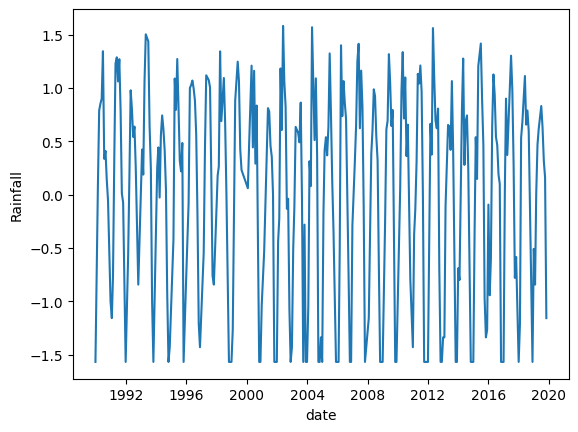

In [18]:
import seaborn as sns
sns.lineplot(x="date",y="Rainfall",data=rain_clean)

<Axes: xlabel='date', ylabel='CHIRPS'>

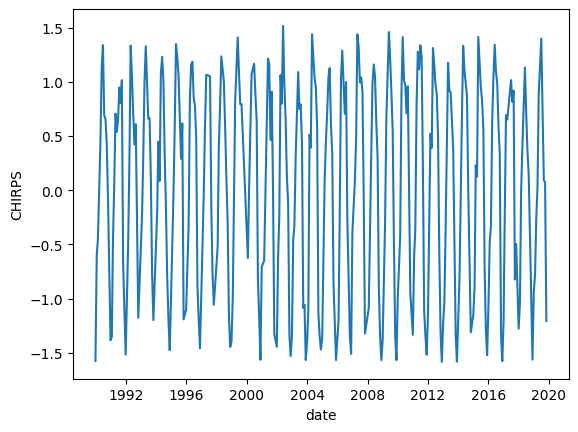

In [19]:
sns.lineplot(x="date",y="CHIRPS",data=rain_clean)

<Axes: xlabel='date', ylabel='ERA5'>

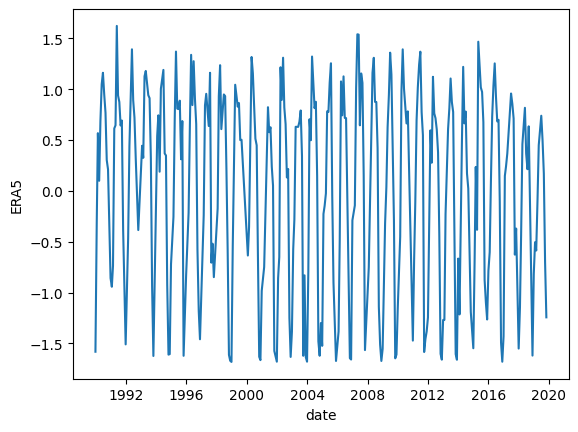

In [20]:
sns.lineplot(x="date",y="ERA5",data=rain_clean)

rain_clean = pd.read_csv("/content/drive/MyDrive/Projects/OMON Rnn/DATA/FINAl/rain_clean.csv")

In [21]:
# Ensure the date column is in datetime format
rain_clean["date"] = pd.to_datetime(rain_clean["date"])

# Set the date as the index
rain_clean.set_index("date", inplace=True)

# Split the data based on the year
train_set = rain_clean[rain_clean.index.year <= 2010]
test_set = rain_clean[rain_clean.index.year >= 2011]
val_set = rain_clean[rain_clean.index.year >= 2016]
# Display the shapes to confirm the split
print("Training Set Shape:", train_set.shape)
print("Testing Set Shape:", test_set.shape)
print("Validation Set Shape:", val_set.shape)

Training Set Shape: (211, 4)
Testing Set Shape: (93, 4)
Validation Set Shape: (40, 4)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_39408\1805623007.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rain_clean["date"] = pd.to_datetime(rain_clean["date"])


In [22]:
x_train=train_set.drop(["Rainfall"],axis=1)
y_train=train_set["Rainfall"]

In [23]:
x_test=test_set.drop(["Rainfall"],axis=1)
y_test=test_set["Rainfall"]

In [24]:
x_val=val_set.drop(["Rainfall"],axis=1)
y_val=val_set["Rainfall"]

In [25]:
x_train.shape,y_train.shape

((211, 3), (211,))

In [26]:
x_test.shape,y_test.shape

((93, 3), (93,))

In [27]:
x_val.shape,y_val.shape

((40, 3), (40,))

### Let me walk You the through the process:
\\\ there the values from (2001-2019) and for each year it consists of 12 month.
### 1.  Sampling Rate:
---The interval at which you sample the data.
---It should reflect the granularity of the time sequence. If you are dealing with monthly data and want to maintain the sequence at a monthly level, the sampling rate can be 1, indicating that the data is sampled each month.
### 2. Sequence Length:
---The number of previous time steps to include in each input sequence.
---This determines how many previous time steps (months) you will use to predict the next. A reasonable starting point for monthly data might be 12, indicating that you use one year of data to make predictions.
### 3. Batch Size:
---The number of sequences to process together in each training iteration.
---Given that you only have 96 rows, a smaller batch size (like 1 or 2) would allow more frequent updates during training.

# Changed From Here

In [28]:
import tensorflow as tf
from tensorflow import keras

# Set random seed for reproducibility
tf.random.set_seed(1234)

# Define sampling parameters
sampling_rate = 1
sequence_length = 9  # 9 months of input data
prediction_horizon = 3  # Predict the next 3 months
batch_size = 1 ###Customize batch size here [1,2,3]

# Create the training dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    data=x_train[:-prediction_horizon],  # Exclude the last 3 months
    targets=y_train[prediction_horizon:],  # Start targets after 9 months
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size
)

# Create the testing dataset
test_dataset = keras.utils.timeseries_dataset_from_array(
    data=x_test[:-prediction_horizon],  # Exclude the last 3 months
    targets=y_test[prediction_horizon:],  # Start targets after 9 months
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,  # No shuffling for testing
    batch_size=batch_size
)

# Create the validation dataset
val_dataset = keras.utils.timeseries_dataset_from_array(
    data=x_val[:-prediction_horizon],  # Exclude the last 3 months
    targets=y_val[prediction_horizon:],  # Start targets after 9 months
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,  # No shuffling for validation
    batch_size=batch_size
)

# Print dataset samples for verification
for x, y in train_dataset.take(1):
    print("Input shape:", x.shape)
    print("Target shape:", y.shape)


Input shape: (1, 9, 3)
Target shape: (1,)


In [29]:
from keras import layers

In [30]:
def r2_score(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())

### Attention sequence model architechture

In [31]:
class AttentionSeq(keras.layers.Layer):
    def __init__(self, units, kernal, dropout, num_heads, key_dim, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.kernal = kernal

        self.conv = layers.Conv1D(units, kernal,padding="same")
        self.activation = layers.Activation("relu")
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.dropout = layers.Dropout(dropout)

    def call(self, inputs):
        # Initial convolutional layer
        x = self.conv(inputs)
        residual = x  # Initial residual connection from conv layer output

        for i in range(4):  # Self-attention mechanism
            attention_output = self.attention(x, x)  # Self-attention on x
            attention_output = self.activation(attention_output)
            x = attention_output + residual  # Residual connection after each attention layer

            # Update residual to x for the next iteration
            residual = x

        x = self.conv(x)  # Final Conv1D to aggregate features
        x = self.dropout(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
            "dropout": self.dropout_rate,
            "num_heads": self.num_heads,
            "key_dim": self.key_dim,
            "kernal": self.kernal
        })
        return config


In [32]:
inputs = layers.Input(shape=(sequence_length, 3))
#x=layers.LSTM(64,recurrent_dropout=0.1,return_sequences=True)(inputs)
x=layers.Conv1D(64, kernel_size=3)(inputs)

x = AttentionSeq(64,3, 0.5, 2, 2)(x)

# Replace Flatten with GlobalAveragePooling1D
x=layers.Flatten()(x)
outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

In [33]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 9, 3)]            0         
                                                                 
 conv1d (Conv1D)             (None, 7, 64)             640       
                                                                 
 attention_seq (AttentionSeq  (None, 7, 64)            13452     
 )                                                               
                                                                 
 flatten (Flatten)           (None, 448)               0         
                                                                 
 dense (Dense)               (None, 1)                 449       
                                                                 
Total params: 14,541
Trainable params: 14,541
Non-trainable params: 0
_________________________________________________________

In [34]:
callbacks=keras.callbacks.ModelCheckpoint("model_attention_seq.keras",save_best_only=True,monitor="val_loss")
early=keras.callbacks.EarlyStopping(monitor="val_loss",restore_best_weights=True,patience=7)
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.00001),
             loss="mse",
             metrics=[
                  keras.metrics.RootMeanSquaredError(name="rmse"),  # RMSE
                  keras.metrics.MeanAbsoluteError(name="mae"),  # MAE
             ]
             )

import time

start_time = time.time()  




import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
import tensorflow as tf

# List GPUs
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    for i, gpu in enumerate(gpus):
        device_name = f"GPU:{i}"  # Correct format "GPU:0", "GPU:1", etc.
        details = tf.config.experimental.get_memory_info(device_name)  
        print(f"Before Training - {device_name} Memory Usage: {details['current'] / 1e6:.2f} MB")


history = model.fit(train_dataset, validation_data=val_dataset, epochs=50, batch_size=256,callbacks=[callbacks])#, callbacks=[callbacks, early]



if gpus:
    for i, gpu in enumerate(gpus):
        device_name = f"GPU:{i}"  # Correct format "GPU:0", "GPU:1", etc.
        details = tf.config.experimental.get_memory_info(device_name)  
        print(f"after Training - {device_name} Memory Usage: {details['current'] / 1e6:.2f} MB")



end_time = time.time()  # End timing

# Calculate the total training time
total_time = end_time - start_time
print(f"Total Training Time: {total_time:.2f} seconds")

Before Training - GPU:0 Memory Usage: 0.08 MB
Epoch 1/50
200/200 [==============================] - 6s 13ms/step - loss: 1.1120 - rmse: 1.0545 - mae: 0.8787 - val_loss: 0.6996 - val_rmse: 0.8364 - val_mae: 0.7057
Epoch 2/50
200/200 [==============================] - 2s 12ms/step - loss: 0.5971 - rmse: 0.7727 - mae: 0.6304 - val_loss: 0.4037 - val_rmse: 0.6354 - val_mae: 0.5292
Epoch 3/50
200/200 [==============================] - 3s 12ms/step - loss: 0.4493 - rmse: 0.6703 - mae: 0.5456 - val_loss: 0.2621 - val_rmse: 0.5119 - val_mae: 0.4342
Epoch 4/50
200/200 [==============================] - 2s 12ms/step - loss: 0.2902 - rmse: 0.5387 - mae: 0.4093 - val_loss: 0.2090 - val_rmse: 0.4572 - val_mae: 0.3922
Epoch 5/50
200/200 [==============================] - 2s 12ms/step - loss: 0.3188 - rmse: 0.5646 - mae: 0.4580 - val_loss: 0.1811 - val_rmse: 0.4256 - val_mae: 0.3726
Epoch 6/50
200/200 [==============================] - 2s 12ms/step - loss: 0.2611 - rmse: 0.5110 - mae: 0.4034 - val_lo

200/200 [==============================] - 2s 12ms/step - loss: 0.1169 - rmse: 0.3418 - mae: 0.2733 - val_loss: 0.0850 - val_rmse: 0.2916 - val_mae: 0.2415
Epoch 50/50
200/200 [==============================] - 2s 12ms/step - loss: 0.0997 - rmse: 0.3158 - mae: 0.2525 - val_loss: 0.0864 - val_rmse: 0.2939 - val_mae: 0.2440
after Training - GPU:0 Memory Usage: 0.15 MB
Total Training Time: 127.63 seconds


In [35]:
#model= keras.models.load_model("model_attention_seq.keras",custom_objects={"AttentionSeq": AttentionSeq})

In [36]:
# Evaluate on the test dataset
#results = model.evaluate(test_dataset)


In [37]:
# Make predictions on the test dataset
predictions = model.predict(test_dataset)

# Convert predictions and true labels to arrays for comparison
y_pred = predictions#.flatten()  # Predicted values
y_true = []  # True values

# Extract the true labels from the test dataset
for _, y in test_dataset:
    y_true.extend(y.numpy())

# Convert to numpy array for easier analysis
y_true = np.array(y_true)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")


82/82 [==============================] - 0s 4ms/step
RMSE: 0.2916
MAE: 0.2343
R-squared: 0.9152


82/82 [==============================] - 0s 4ms/step


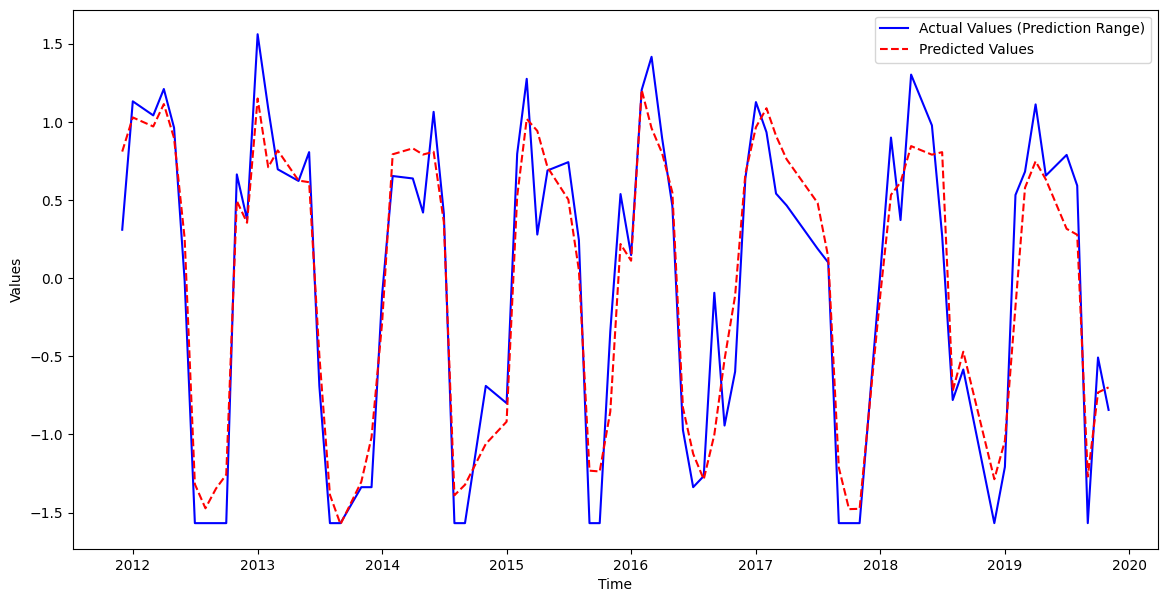

In [38]:
# Extract true labels from test_dataset
y_true = []
for _, y in test_dataset:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

# Generate predictions
y_pred = model.predict(test_dataset)#.flatten()

# Use the full dataset's date range for the x-axis
full_time_index = rain_clean.index  # Assumes `rain_clean` has datetime index

# Determine the start of the prediction range
start_index = len(rain_clean) - len(y_true)

# Plot
plt.figure(figsize=(14,7))
plt.plot(full_time_index[start_index:], y_true, label="Actual Values (Prediction Range)", color="blue", linestyle="-")
plt.plot(full_time_index[start_index:], y_pred, label="Predicted Values", color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()

# Dynamically determine the position for the metrics text
x_limits = plt.gca().get_xlim()  # Get current x-axis limits
y_limits = plt.gca().get_ylim()  # Get current y-axis limits

# Place the text in the top-left corner of the plot
x_pos = x_limits[0] + 0.02 * (x_limits[1] - x_limits[0])  # 2% from the left
y_pos = y_limits[1] - 0.1 * (y_limits[1] - y_limits[0])   # 10% down from the top


plt.show()


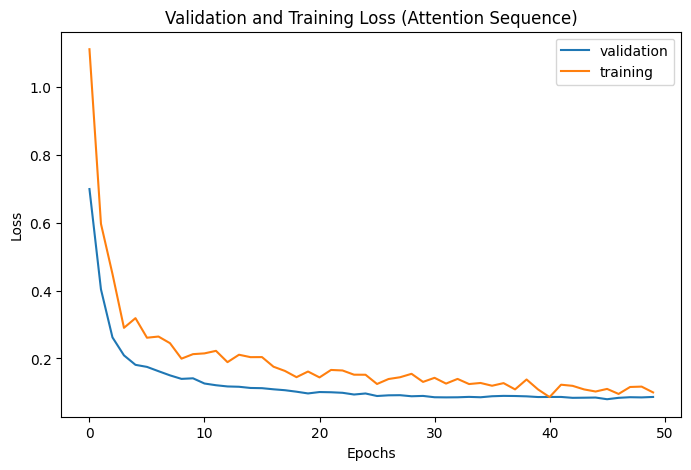

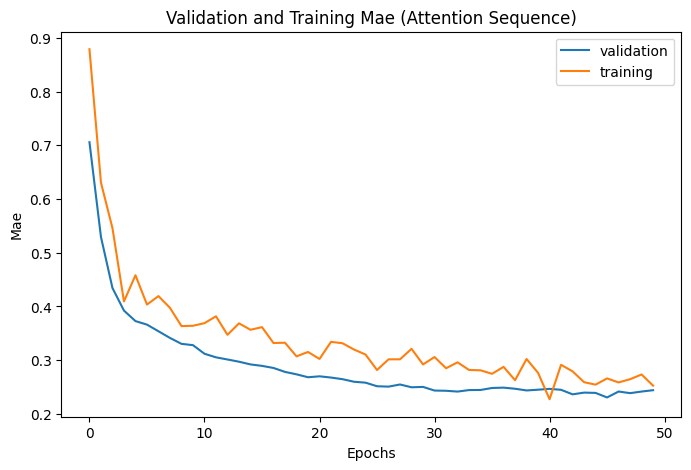

In [39]:
#attention epochs plot
df = pd.DataFrame({
    "validation": history.history["val_loss"],
    "training": history.history["loss"]
})

# Plot the data
df.plot(figsize=(8, 5))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation and Training Loss (Attention Sequence)")
plt.legend()
plt.show()

df2 = pd.DataFrame({
    "validation": history.history["val_mae"],
    "training": history.history["mae"]
})

# Plot the data
df2.plot(figsize=(8, 5))
plt.xlabel("Epochs")
plt.ylabel("Mae")
plt.title("Validation and Training Mae (Attention Sequence)")
plt.legend()
plt.show()

# LSTM

In [40]:
import datetime

In [41]:
inputs = layers.Input(shape=(sequence_length, 3))
x = layers.LSTM(64, recurrent_dropout=0.1, return_sequences=True)(inputs)
x=layers.Flatten()(x)
outputs = layers.Dense(1)(x)
model_lstm_only = keras.Model(inputs, outputs)

In [42]:
callbacks_lstm=keras.callbacks.ModelCheckpoint("model_lstm_only.keras",save_best_only=True,monitor="val_loss")

early=keras.callbacks.EarlyStopping(monitor="val_loss",restore_best_weights=True,patience=7)
model_lstm_only.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.00001),
             loss="mse",
             metrics=[
                  keras.metrics.RootMeanSquaredError(name="rmse"),  # RMSE
                  keras.metrics.MeanAbsoluteError(name="mae"),  # MAE
             ]
             )


start_time = time.time()


if gpus:
    for i, gpu in enumerate(gpus):
        device_name = f"GPU:{i}"  # Correct format "GPU:0", "GPU:1", etc.
        details = tf.config.experimental.get_memory_info(device_name)  
        print(f"Before Training - {device_name} Memory Usage: {details['current'] / 1e6:.2f} MB")



history3=model_lstm_only.fit(train_dataset,validation_data=val_dataset,epochs=50,batch_size=256)#callbacks=[callbacks_lstm,early]

if gpus:
    for i, gpu in enumerate(gpus):
        device_name = f"GPU:{i}"  # Correct format "GPU:0", "GPU:1", etc.
        details = tf.config.experimental.get_memory_info(device_name)  
        print(f"after Training - {device_name} Memory Usage: {details['current'] / 1e6:.2f} MB")

end_time = time.time()  # End timing

# Calculate the total training time
total_time = end_time - start_time
print(f"Total Training Time: {total_time:.2f} seconds")

Before Training - GPU:0 Memory Usage: 0.25 MB
Epoch 1/50
200/200 [==============================] - 11s 47ms/step - loss: 0.8634 - rmse: 0.9292 - mae: 0.7999 - val_loss: 0.8199 - val_rmse: 0.9055 - val_mae: 0.7926
Epoch 2/50
200/200 [==============================] - 9s 47ms/step - loss: 0.7941 - rmse: 0.8911 - mae: 0.7628 - val_loss: 0.7636 - val_rmse: 0.8738 - val_mae: 0.7618
Epoch 3/50
200/200 [==============================] - 9s 46ms/step - loss: 0.7285 - rmse: 0.8535 - mae: 0.7267 - val_loss: 0.7104 - val_rmse: 0.8428 - val_mae: 0.7308
Epoch 4/50
200/200 [==============================] - 10s 48ms/step - loss: 0.6653 - rmse: 0.8157 - mae: 0.6894 - val_loss: 0.6601 - val_rmse: 0.8124 - val_mae: 0.6997
Epoch 5/50
200/200 [==============================] - 9s 47ms/step - loss: 0.6076 - rmse: 0.7795 - mae: 0.6541 - val_loss: 0.6136 - val_rmse: 0.7833 - val_mae: 0.6690
Epoch 6/50
200/200 [==============================] - 10s 47ms/step - loss: 0.5544 - rmse: 0.7446 - mae: 0.6198 - val

200/200 [==============================] - 10s 49ms/step - loss: 0.1398 - rmse: 0.3738 - mae: 0.2953 - val_loss: 0.1995 - val_rmse: 0.4467 - val_mae: 0.3879
Epoch 50/50
200/200 [==============================] - 10s 49ms/step - loss: 0.1378 - rmse: 0.3712 - mae: 0.2937 - val_loss: 0.1987 - val_rmse: 0.4458 - val_mae: 0.3873
after Training - GPU:0 Memory Usage: 0.35 MB
Total Training Time: 484.36 seconds


In [43]:
#model_lstm_only= keras.models.load_model("model_lstm_only.keras")
#results3=model_lstm_only.evaluate(test_dataset)

In [44]:
# Make predictions on the test dataset
predictions = model_lstm_only.predict(test_dataset)

# Convert predictions and true labels to arrays for comparison
y_pred = predictions#.flatten()  # Predicted values
y_true = []  # True values

# Extract the true labels from the test dataset
for _, y in test_dataset:
    y_true.extend(y.numpy())

# Convert to numpy array for easier analysis
y_true = np.array(y_true)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")


82/82 [==============================] - 1s 9ms/step
RMSE: 0.4412
MAE: 0.3733
R-squared: 0.8058


82/82 [==============================] - 1s 8ms/step


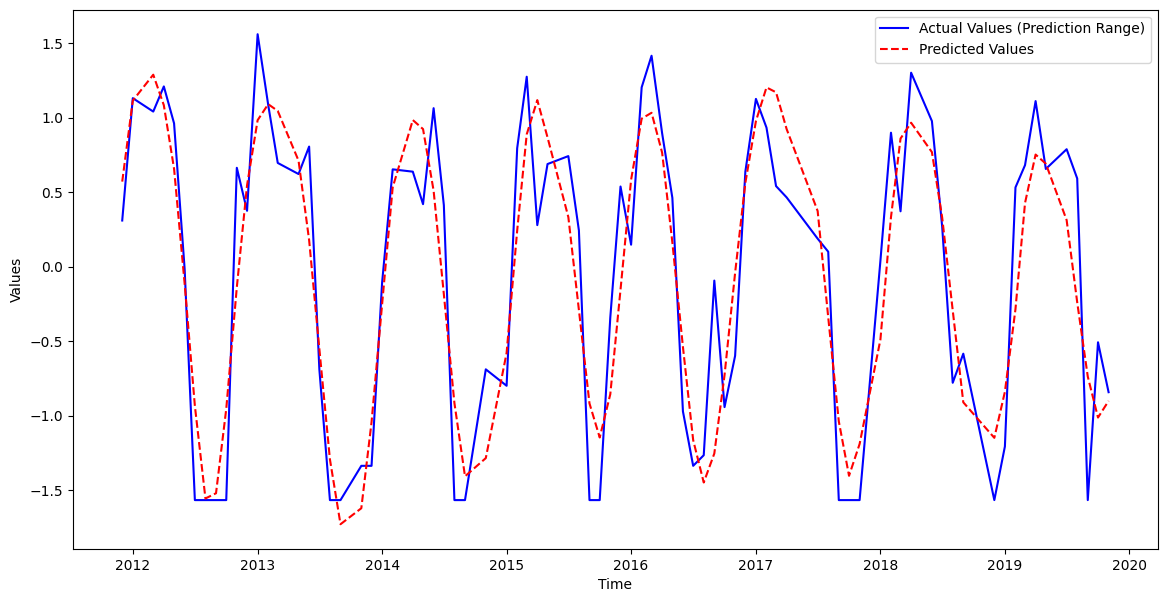

In [45]:
# Extract true labels from test_dataset
y_true = []
for _, y in test_dataset:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

# Generate predictions
y_pred = model_lstm_only.predict(test_dataset)#.flatten()

# Use the full dataset's date range for the x-axis
full_time_index = rain_clean.index  # Assumes `rain_clean` has datetime index

# Determine the start of the prediction range
start_index = len(rain_clean) - len(y_true)

# Plot
plt.figure(figsize=(14,7))
plt.plot(full_time_index[start_index:], y_true, label="Actual Values (Prediction Range)", color="blue", linestyle="-")
plt.plot(full_time_index[start_index:], y_pred, label="Predicted Values", color="red", linestyle="--")

plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()


# Dynamically determine the position for the metrics text
x_limits = plt.gca().get_xlim()  # Get current x-axis limits
y_limits = plt.gca().get_ylim()  # Get current y-axis limits

# Place the text in the top-left corner of the plot
x_pos = x_limits[0] + 0.02 * (x_limits[1] - x_limits[0])  # 2% from the left
y_pos = y_limits[1] - 0.1 * (y_limits[1] - y_limits[0])   # 10% down from the top


plt.show()


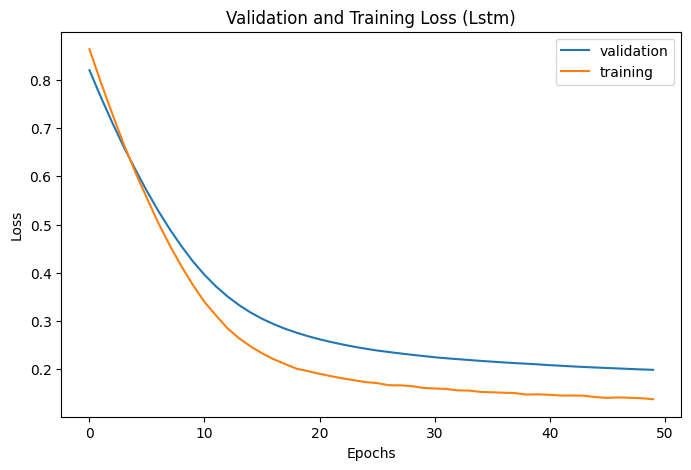

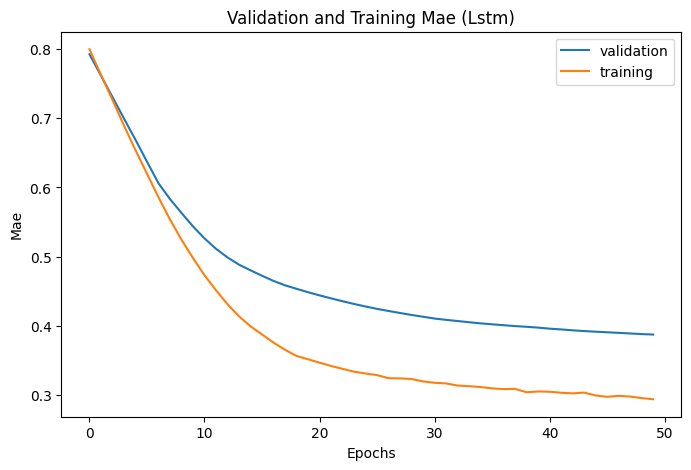

In [46]:
df = pd.DataFrame({
    "validation": history3.history["val_loss"],
    "training": history3.history["loss"]
})

# Plot the data
df.plot(figsize=(8, 5))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation and Training Loss (Lstm)")
plt.legend()
plt.show()

df2 = pd.DataFrame({
    "validation": history3.history["val_mae"],
    "training": history3.history["mae"]
})

# Plot the data
df2.plot(figsize=(8, 5))
plt.xlabel("Epochs")
plt.ylabel("Mae")
plt.title("Validation and Training Mae (Lstm)")
plt.legend()
plt.show()

# Convolstm

In [47]:
# Define the LSTM model
inputs = layers.Input(shape=(sequence_length, 3))
x = layers.LSTM(64, recurrent_dropout=0.1, return_sequences=True)(inputs)
x = layers.Conv1D(64, kernel_size=3)(x)
# Replace Flatten with GlobalAveragePooling1D
x=layers.Flatten()(x)
outputs = layers.Dense(1)(x)
model_lstm = keras.Model(inputs, outputs)


In [48]:
callbacks2=keras.callbacks.ModelCheckpoint("model_lstm.keras",save_best_only=True,monitor="val_loss")
early=keras.callbacks.EarlyStopping(monitor="val_loss",restore_best_weights=True,patience=7)
model_lstm.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.00001),
             loss="mse",
             metrics=[
                  keras.metrics.RootMeanSquaredError(name="rmse"),  # RMSE
                  keras.metrics.MeanAbsoluteError(name="mae"),  # MAE
             ]
             )


start_time = time.time()

if gpus:
    for i, gpu in enumerate(gpus):
        device_name = f"GPU:{i}"  # Correct format "GPU:0", "GPU:1", etc.
        details = tf.config.experimental.get_memory_info(device_name)  
        print(f"Before Training - {device_name} Memory Usage: {details['current'] / 1e6:.2f} MB")

history2=model_lstm.fit(train_dataset,validation_data=val_dataset,epochs=50,batch_size=256)#,callbacks=[callbacks2,early]

if gpus:
    for i, gpu in enumerate(gpus):
        device_name = f"GPU:{i}"  # Correct format "GPU:0", "GPU:1", etc.
        details = tf.config.experimental.get_memory_info(device_name)  
        print(f"after Training - {device_name} Memory Usage: {details['current'] / 1e6:.2f} MB")


end_time = time.time()  # End timing

# Calculate the total training time
total_time = end_time - start_time
print(f"Total Training Time: {total_time:.2f} seconds")

Before Training - GPU:0 Memory Usage: 0.51 MB
Epoch 1/50
200/200 [==============================] - 12s 49ms/step - loss: 0.6498 - rmse: 0.8061 - mae: 0.6715 - val_loss: 0.6216 - val_rmse: 0.7884 - val_mae: 0.6686
Epoch 2/50
200/200 [==============================] - 10s 49ms/step - loss: 0.5016 - rmse: 0.7082 - mae: 0.5779 - val_loss: 0.5091 - val_rmse: 0.7135 - val_mae: 0.5985
Epoch 3/50
200/200 [==============================] - 10s 49ms/step - loss: 0.3893 - rmse: 0.6239 - mae: 0.5055 - val_loss: 0.4239 - val_rmse: 0.6511 - val_mae: 0.5491
Epoch 4/50
200/200 [==============================] - 10s 48ms/step - loss: 0.3080 - rmse: 0.5550 - mae: 0.4437 - val_loss: 0.3625 - val_rmse: 0.6021 - val_mae: 0.5050
Epoch 5/50
200/200 [==============================] - 10s 48ms/step - loss: 0.2548 - rmse: 0.5048 - mae: 0.4013 - val_loss: 0.3208 - val_rmse: 0.5664 - val_mae: 0.4842
Epoch 6/50
200/200 [==============================] - 10s 49ms/step - loss: 0.2219 - rmse: 0.4711 - mae: 0.3732 - 

200/200 [==============================] - 10s 49ms/step - loss: 0.0968 - rmse: 0.3112 - mae: 0.2462 - val_loss: 0.1520 - val_rmse: 0.3898 - val_mae: 0.3341
Epoch 50/50
200/200 [==============================] - 10s 49ms/step - loss: 0.0964 - rmse: 0.3105 - mae: 0.2470 - val_loss: 0.1512 - val_rmse: 0.3888 - val_mae: 0.3332
after Training - GPU:0 Memory Usage: 0.61 MB
Total Training Time: 495.37 seconds


In [49]:
#model_lstm= keras.models.load_model("model_lstm.keras")
#results2=model_lstm.evaluate(test_dataset)

In [50]:
# Make predictions on the test dataset
predictions = model_lstm.predict(test_dataset)

# Convert predictions and true labels to arrays for comparison
y_pred = predictions#.flatten()  # Predicted values
y_true = []  # True values

# Extract the true labels from the test dataset
for _, y in test_dataset:
    y_true.extend(y.numpy())

# Convert to numpy array for easier analysis
y_true = np.array(y_true)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Compute metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R-squared: {r2:.4f}")


82/82 [==============================] - 1s 8ms/step
RMSE: 0.3868
MAE: 0.3226
R-squared: 0.8507


82/82 [==============================] - 1s 8ms/step


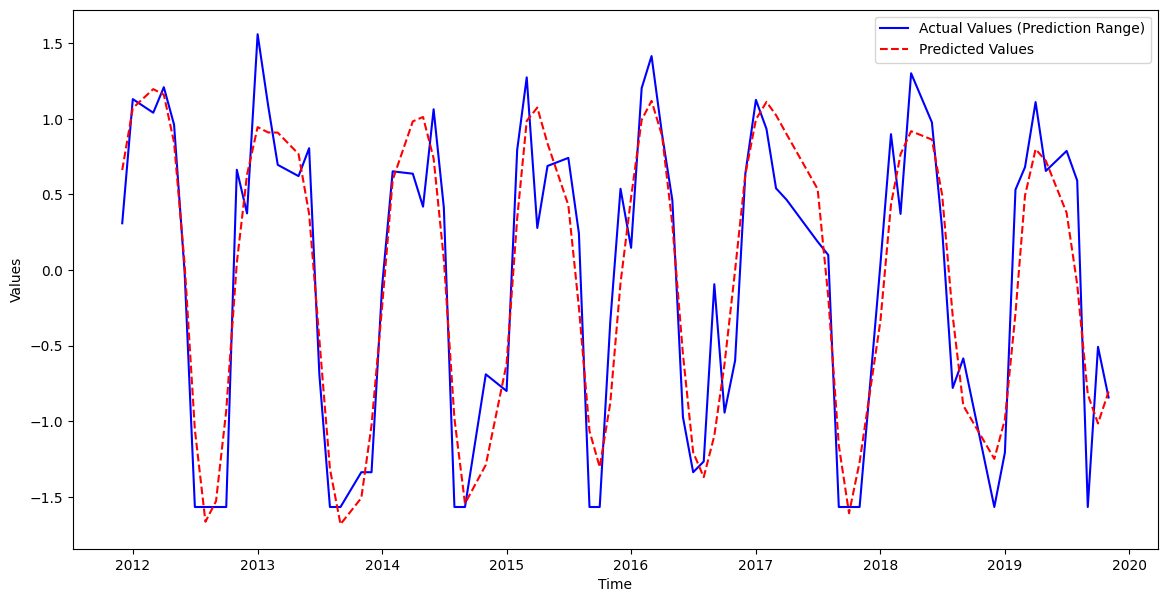

In [51]:
# Extract true labels from test_dataset
y_true = []
for _, y in test_dataset:
    y_true.extend(y.numpy())
y_true = np.array(y_true)

# Generate predictions
y_pred = model_lstm.predict(test_dataset)#.flatten()

# Use the full dataset's date range for the x-axis
full_time_index = rain_clean.index  # Assumes `rain_clean` has datetime index

# Determine the start of the prediction range
start_index = len(rain_clean) - len(y_true)

# Plot
plt.figure(figsize=(14,7))
plt.plot(full_time_index[start_index:], y_true, label="Actual Values (Prediction Range)", color="blue", linestyle="-")
plt.plot(full_time_index[start_index:], y_pred, label="Predicted Values", color="red", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Values")
plt.legend()


# Dynamically determine the position for the metrics text
x_limits = plt.gca().get_xlim()  # Get current x-axis limits
y_limits = plt.gca().get_ylim()  # Get current y-axis limits

# Place the text in the top-left corner of the plot
x_pos = x_limits[0] + 0.02 * (x_limits[1] - x_limits[0])  # 2% from the left
y_pos = y_limits[1] - 0.1 * (y_limits[1] - y_limits[0])   # 10% down from the top


plt.show()


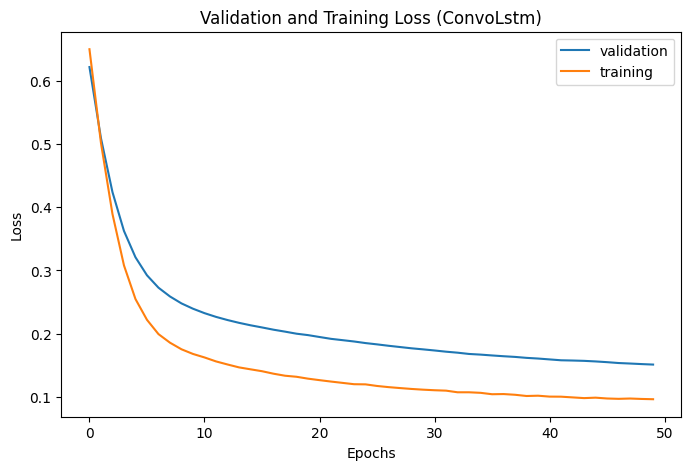

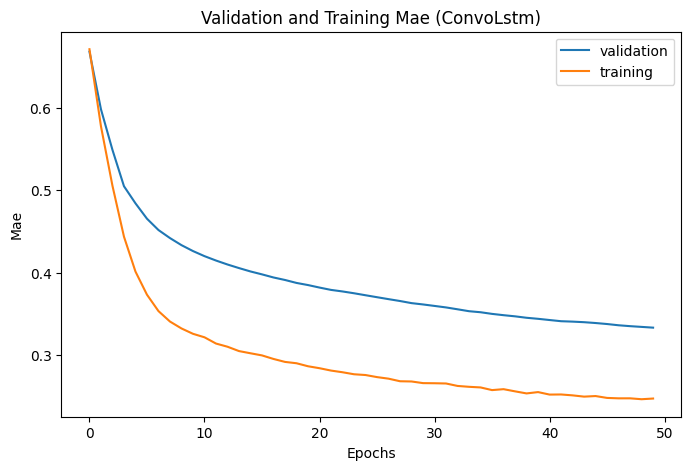

In [52]:


df = pd.DataFrame({
    "validation": history2.history["val_loss"],
    "training": history2.history["loss"]
})

# Plot the data
df.plot(figsize=(8, 5))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation and Training Loss (ConvoLstm)")
plt.legend()
plt.show()

df2 = pd.DataFrame({
    "validation": history2.history["val_mae"],
    "training": history2.history["mae"]
})

# Plot the data
df2.plot(figsize=(8, 5))
plt.xlabel("Epochs")
plt.ylabel("Mae")
plt.title("Validation and Training Mae (ConvoLstm)")
plt.legend()
plt.show()

## LIME

### Lime for attention sequence

In [53]:
import lime
import lime.lime_tabular
import numpy as np

import numpy as np
import lime
import lime.lime_tabular

feature_names = ["CHIRPS","ERA5","PERSIANN"]


import numpy as np
import lime
import lime.lime_tabular

# Convert the dataset to arrays
x_train_array, y_train_array = [], []

for x, y in train_dataset:
    x_train_array.append(x.numpy())  # Keep the original shape
    y_train_array.append(y.numpy())

x_train_seq = np.array(x_train_array)
y_train_seq = np.array(y_train_array)

# Custom perturbation function for time-series
def perturb_timeseries(data_instance):
    perturbed_instance = data_instance.copy()
    num_timesteps = perturbed_instance.shape[0]
    # Randomly mask a third of the time steps
    time_steps_to_perturb = np.random.choice(num_timesteps, size=int(num_timesteps / 3), replace=False)
    perturbed_instance[time_steps_to_perturb, :] = 0  # Zero-out the selected time steps
    return perturbed_instance

# Wrapper function for LIME to generate perturbations and call the LSTM model
def timeseries_predict_wrapper(data_instances):
    predictions = []
    for instance in data_instances:
        instance = instance.reshape(1, sequence_length, len(feature_names))  # Reshape for LSTM
        prediction = model.predict(instance)
        predictions.append(prediction[0])  # Assuming a single prediction for the entire sequence
    return np.array(predictions)

# Initialize LIME explainer with feature names
explainer = lime.lime_tabular.LimeTabularExplainer(
    x_train_seq.reshape(x_train_seq.shape[0], -1),  # Flatten for LIME initialization
    mode='regression',
    feature_names=[f'{feature}_{t}' for t in range(sequence_length) for feature in feature_names],  # Combine feature names and time steps
    verbose=True
)

# Choose a specific instance from the test dataset to explain
x_test_array = []
for x, y in test_dataset:
    x_test_array.append(x.numpy())

x_test_seq = np.array(x_test_array)

# Select a specific instance from the test data to explain
instance_to_explain = x_test_seq[0]

# Explain the model's prediction for this instance
exp = explainer.explain_instance(
    instance_to_explain.reshape(-1),  # Flatten for LIME, but perturbed in original shape
    timeseries_predict_wrapper,
    num_features=sequence_length * len(feature_names),  # Number of time steps and features
    top_labels=1
)

# Display the explanation
exp.show_in_notebook()
exp.save_to_file('lime_explanation.html')

1/1 [==============================] - 0s 25ms/step


1/1 [==============================] - 0s 24ms/step


1/1 [==============================] - 0s 25ms/step


1/1 [==============================] - 0s 28ms/step


1/1 [==============================] - 0s 24ms/step


...

1/1 [==============================] - 0s 25ms/step


1/1 [==============================] - 0s 24ms/step


1/1 [==============================] - 0s 26ms/step


1/1 [==============================] - 0s 25ms/step


1/1 [==============================] - 0s 28ms/step
Intercept -0.2036768217559102
Prediction_local [0.84004382]
Right: 0.80957544


### Lime for convolstm

In [54]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        xtest=np.concatenate([x[0].numpy() for x in train_dataset],axis=0)
        print(xtest)

[[[-0.60272333 -0.31881017 -0.55264943]
  [-0.45348973  0.56716012  0.44028183]
  [-0.00250367  0.09923701  0.18086988]
  ...
  [ 0.68986099  0.94767911  0.62365824]
  [ 0.65715081  0.7682219   0.79507036]
  [ 0.43105921  0.30248353  0.81693982]]

 [[ 0.08108583 -0.14366202  0.33726397]
  [ 0.47243728  1.0083276   0.76131473]
  [ 1.4390459   1.53975216  1.16550277]
  ...
  [ 0.91311287  1.06178321  1.11549699]
  [-0.03697498  0.15298422  0.13187894]
  [-1.32338629 -1.56584261 -1.57483642]]

 [[ 1.34937781  1.36964891  1.25439588]
  [ 1.22692541  0.8085591   0.95553965]
  [ 1.06697904  0.80389416  0.79788876]
  ...
  [-1.19171276 -1.62207867 -1.69502051]
  [-1.1032632  -0.83062442 -0.85342095]
  [-0.33296493 -0.21564176 -0.44774055]]

 ...

 [[ 1.00712845  0.94792315  0.73786578]
  [ 0.58096211  0.93171334  0.56121527]
  [ 0.10373612  0.21609757  0.01841669]
  ...
  [-1.39743033 -1.68230472 -1.33155715]
  [-1.00793443 -0.54234179 -0.98947012]
  [ 0.83741368  1.04339356  0.88220127]]

 [

In [55]:
xtest[0]

array([[-0.60272333, -0.31881017, -0.55264943],
       [-0.45348973,  0.56716012,  0.44028183],
       [-0.00250367,  0.09923701,  0.18086988],
       [ 0.44218223,  0.68444717,  0.76388501],
       [ 1.12296292,  1.04859281,  0.87644324],
       [ 1.34004931,  1.16102273,  0.79935044],
       [ 0.68986099,  0.94767911,  0.62365824],
       [ 0.65715081,  0.7682219 ,  0.79507036],
       [ 0.43105921,  0.30248353,  0.81693982]])

In [56]:
xtest[1]

array([[ 0.08108583, -0.14366202,  0.33726397],
       [ 0.47243728,  1.0083276 ,  0.76131473],
       [ 1.4390459 ,  1.53975216,  1.16550277],
       [ 1.32269526,  1.53647457,  0.72940984],
       [ 0.99553342,  0.64460192,  0.87823925],
       [ 1.04121469,  1.15440206,  1.46111262],
       [ 0.91311287,  1.06178321,  1.11549699],
       [-0.03697498,  0.15298422,  0.13187894],
       [-1.32338629, -1.56584261, -1.57483642]])

In [57]:
xtest.shape

(200, 9, 3)